# Figure S2

![Full Figure](../figures/suppS2_FULL.png)

## Code For Figure S2A–C: Simulations of Legacy-Trained Animals' Growth Ceiling

**Goal:** Simulate Legacy fixation growth under recovery (empirical violation rates) and perfect (zero violations) conditions to assess whether Legacy animals were limited by an intrinsic growth ceiling.

| Panel | Description | Data source |
|-------|-------------|-------------|
| A | Example R050 trajectories: true, recovery, perfect | `trials_df` + cached sim, **seed 30** (same as old `figS2.ipynb`) |
| B | Legacy true vs recovery days-to-target (Wilcoxon) | mean over **seeds 0–29** + empirical `trials_df` |
| C | Legacy perfect vs FixGrower true (Mann–Whitney) | mean over **seeds 0–29** + empirical `trials_df` |

**Simulation cache:** Each seed is stored as trial-level parquet at  
`data/figS2_simulations/simulation_results_seed_{seed}.parquet`.  
The cell below loads existing files or runs missing seeds (8 Legacy animals × 2 modes per seed).

**Outputs:**
- `figures/suppS2a_r050_example_simulation.png`
- `figures/suppS2b_legacy_recovery_vs_true.png`
- `figures/suppS2c_legacy_perfect_vs_fixgrower_true.png`


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from fixation_grower import config
from fixation_grower.io import load_trials_df
from fixation_grower.plotting import (
    plot_days_to_target_comparison,
    plot_fixation_simulation_example,
    save_figure,
)
from fixation_grower.simulation import (
    LEGACY_SIM_ANIMALS,
    N_SIM_REPLICATES,
    PANEL_A_ANIMAL,
    PANEL_A_SEED,
    SIM_CACHE_SEEDS,
    SIM_SEEDS,
    load_all_simulation_results,
    mean_simulated_days_to_target,
    simulation_results_path,
)
from fixation_grower.stats import compare_legacy_fixgrower, compare_paired_wilcoxon
from fixation_grower.transforms import (
    compute_days_relative_to_stage,
    make_days_to_target_df,
)

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "axes.titleweight": "bold",
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [2]:
tdf = load_trials_df(stages="all")
tdf = compute_days_relative_to_stage(tdf, stage=5)

EXAMPLE_ANIMAL = PANEL_A_ANIMAL
ex_animal_df = tdf.query(
    "animal_id == @EXAMPLE_ANIMAL and stage in @config.GROWING_STAGES"
)

## R050 session diagnostics

Empirical violation rate and trial count per session used to parameterize the Legacy simulator (see Methods) for this animal.

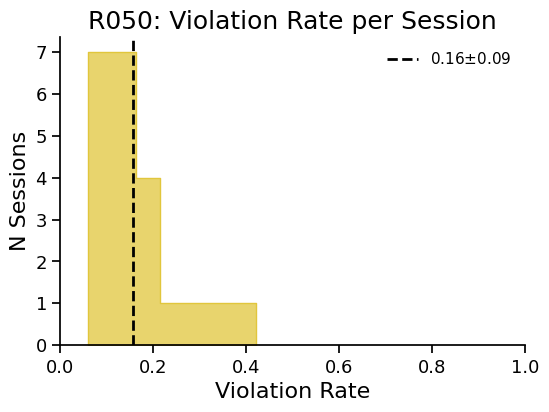

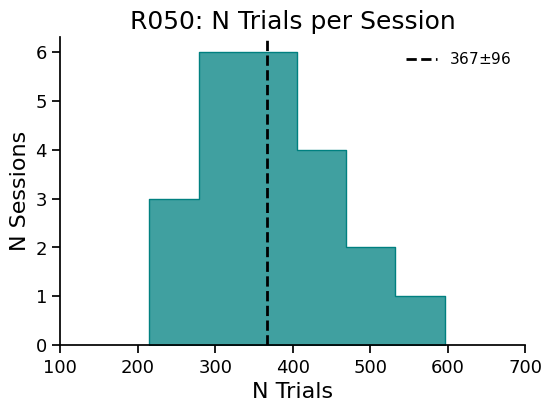

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()
viol_by_date = ex_animal_df.groupby("date")["violations"].mean()
sns.histplot(viol_by_date, ax=ax, color=config.VIOLATION_COLOR, element="step")
mean_v = viol_by_date.mean()
std_v = viol_by_date.std()
ax.axvline(mean_v, color="k", linestyle="--",
           label=f"{mean_v:.2f}$\pm${std_v:.2f}")
ax.set(xlim=(0, 1), ylabel="N Sessions", xlabel="Violation Rate",
       title=f"{EXAMPLE_ANIMAL}: Violation Rate per Session")
ax.legend(frameon=False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
sns.despine()
trials_by_date = ex_animal_df.groupby("date")["trial"].max()
sns.histplot(trials_by_date, ax=ax, color="teal", element="step")
mean_t = trials_by_date.mean()
std_t = trials_by_date.std()
ax.axvline(mean_t, color="k", linestyle="--",
           label=f"{mean_t:.0f}$\pm${std_t:.0f}")
ax.set(xlim=(100, 700), ylabel="N Sessions", xlabel="N Trials",
       title=f"{EXAMPLE_ANIMAL}: N Trials per Session")
ax.legend(frameon=False)
plt.show()

## Simulation cache

`load_all_simulation_results(tdf)` loads trial-level results from parquet when present; otherwise it runs `LegacyFixationGrowthSimulator` for each missing seed and writes cache files.

- **Seeds 0–29:** 30 stochastic replicates averaged for panels B and C
- **Seed 30:** extra cached run for the R050 example trajectory in panel A only.

First run with no cache files takes ~1–3 min; re-runs load from disk.


In [4]:
cache_dir = simulation_results_path(0).parent
n_cached = sum(simulation_results_path(s).exists() for s in SIM_CACHE_SEEDS)
print(
    f"Simulation cache: {n_cached}/{len(SIM_CACHE_SEEDS)} seed files in {cache_dir}"
)
print(
    f"  Replicate seeds (panels B/C): {SIM_SEEDS.start}–{SIM_SEEDS.stop - 1}")
print(f"  Panel A seed: {PANEL_A_SEED}")

sim_all = load_all_simulation_results(tdf)
print(
    f"Loaded {len(sim_all):,} trial-level rows across seeds {sorted(sim_all['seed'].unique())}")

sim_replicates = sim_all.query("seed in @SIM_SEEDS")
sim_mean = mean_simulated_days_to_target(sim_replicates)

true_days = make_days_to_target_df(tdf)
true_days["mode"] = true_days["fix_experiment"].map(
    {"Legacy": "legacy_true", "FixGrower": "fixgrower_true"}
)

summary_df = pd.concat(
    [
        sim_mean[["animal_id", "mode", "days_to_target"]],
        true_days[["animal_id", "mode", "days_to_target"]],
    ],
    ignore_index=True,
)

Simulation cache: 31/31 seed files in /Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/data/figS2_simulations
  Replicate seeds (panels B/C): 0–29
  Panel A seed: 30
Loaded 3,434,401 trial-level rows across seeds [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]


## Panel A — Example simulation (R050)

True growing-stage trials vs recovery and perfect simulations. Uses **seed 30** from the cache (not included in the B/C replicate average).


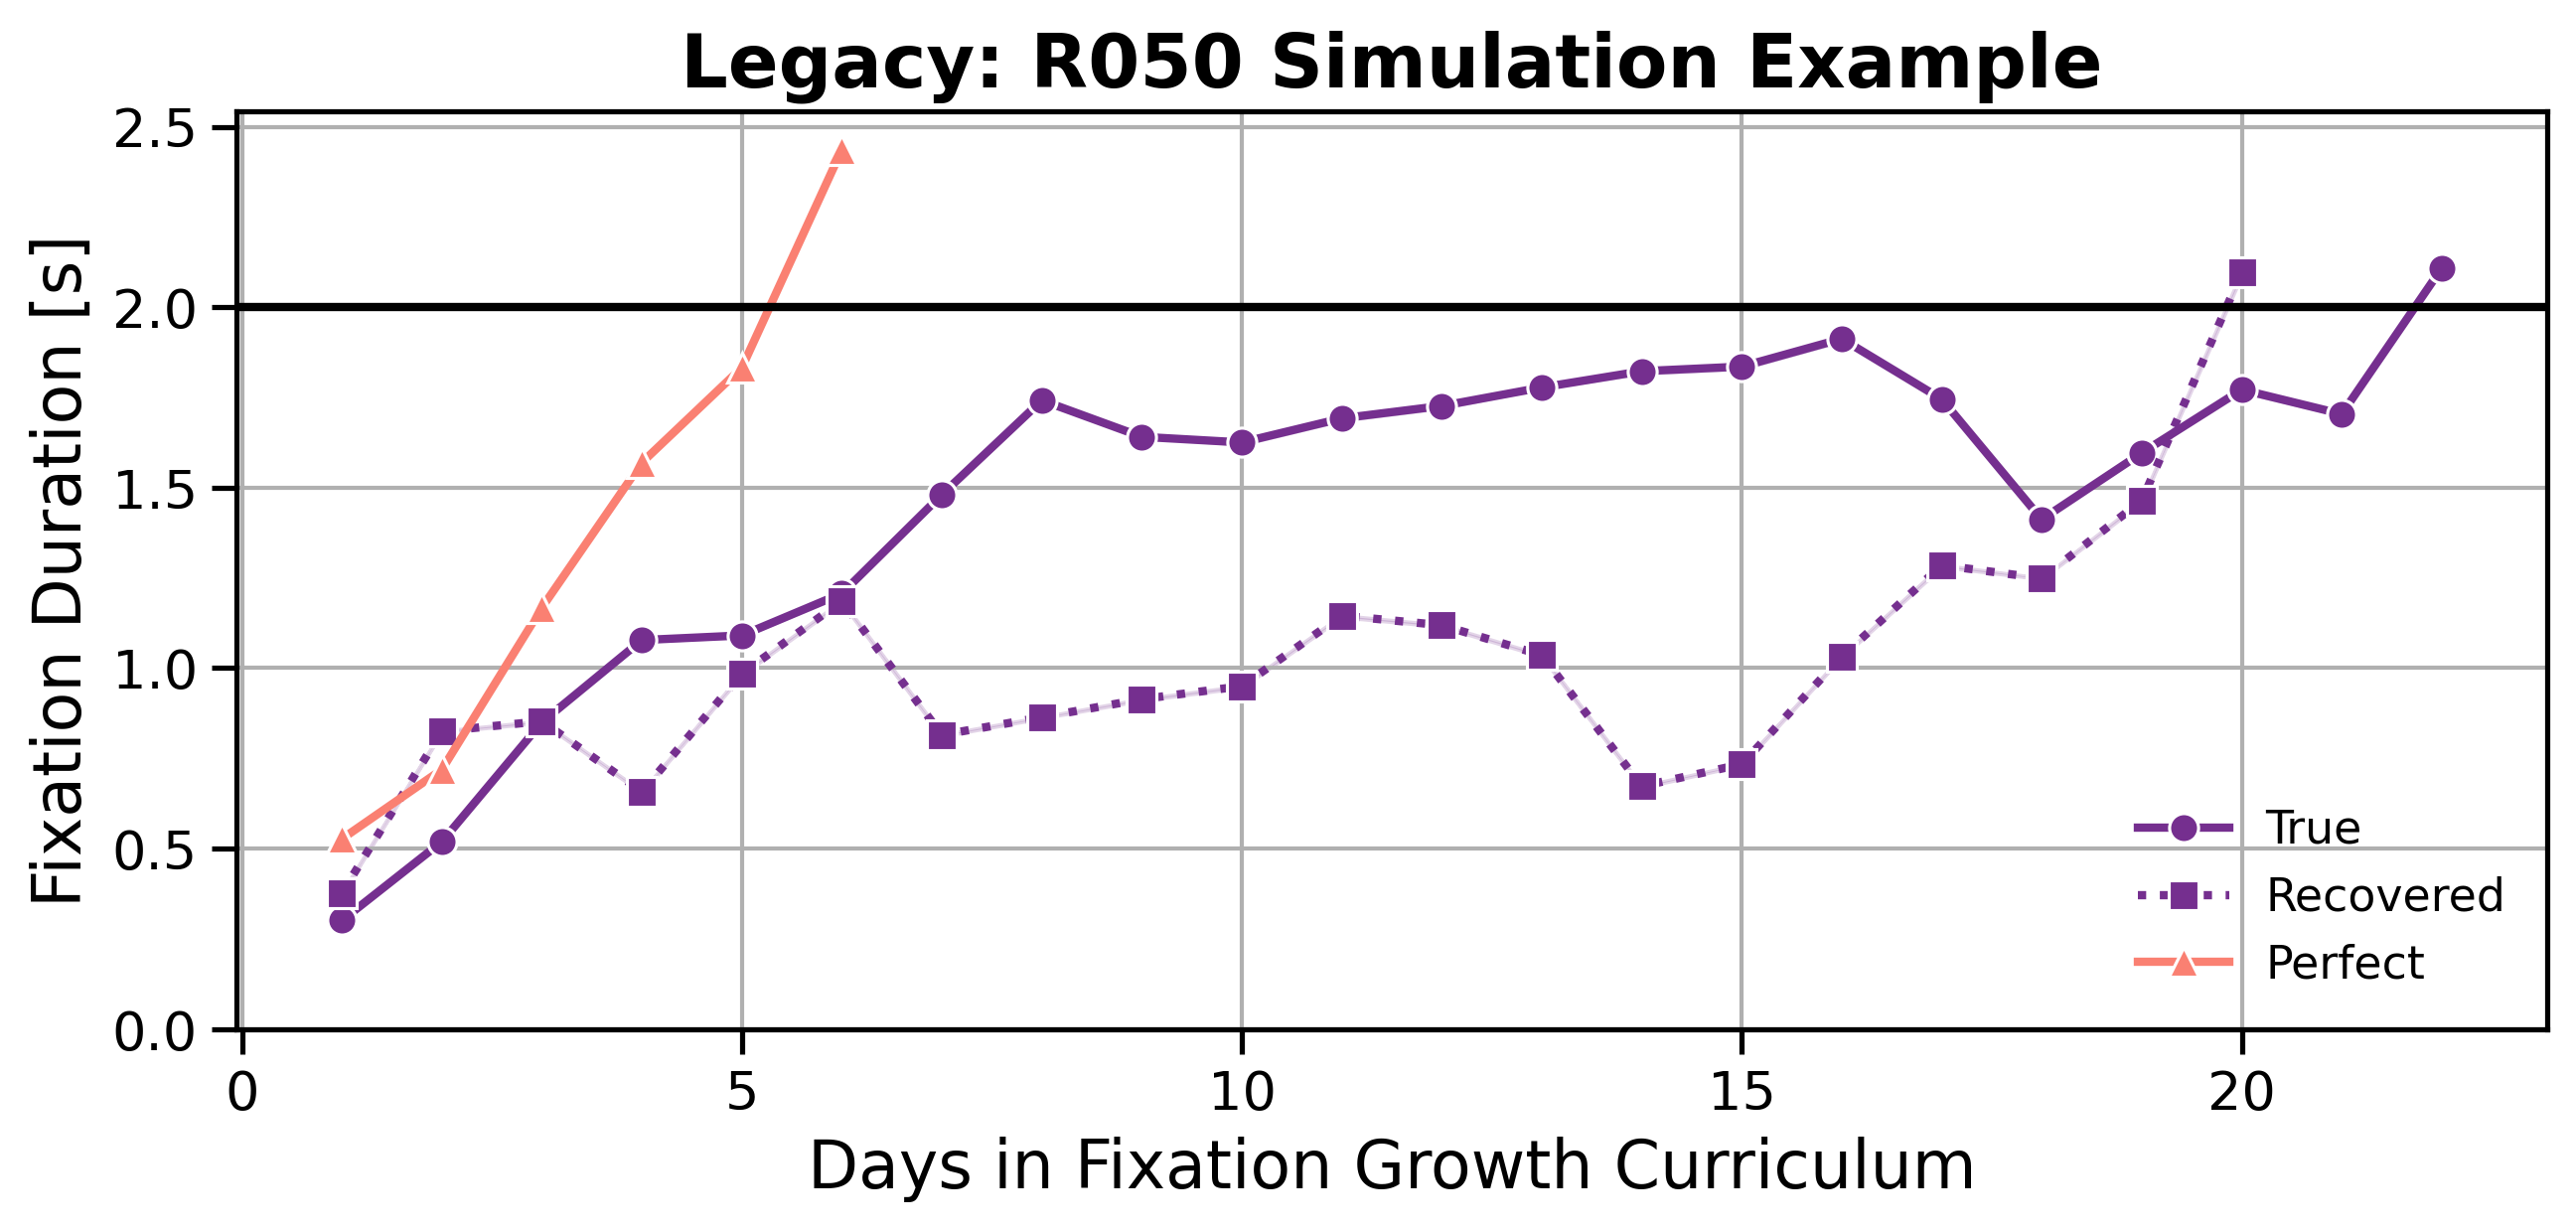

In [8]:
trials_true = ex_animal_df[
    ["animal_id", "days_relative_to_stage_5",
        "fixation_dur", "violations", "trial"]
].copy()
trials_true["session"] = trials_true["days_relative_to_stage_5"] + 1

sim_a = sim_all.query(
    "animal_id == @EXAMPLE_ANIMAL and seed == @PANEL_A_SEED"
)
trials_recovery = sim_a.query("mode == 'recovery'")
trials_perfect = sim_a.query("mode == 'perfect'")

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
plot_fixation_simulation_example(
    ax, trials_true, trials_recovery, trials_perfect)
ax.set_title(f"Legacy: {EXAMPLE_ANIMAL} Simulation Example", fontweight="bold")
ax.legend(frameon=False)
save_figure(fig, "suppS2a_r050_example_simulation")
plt.show()

## Panel B — Recovery vs Legacy true

Wilcoxon signed-rank test on paired Legacy animals (N = 8). Simulated recovery days-to-target are means over **seeds 0–29** only.


/Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/src/fixation_grower/plotting.py:332: UserWarning: 
The palette list has fewer values (8) than needed (17) and will cycle, which may produce an uninterpretable plot.
  sns.pointplot(


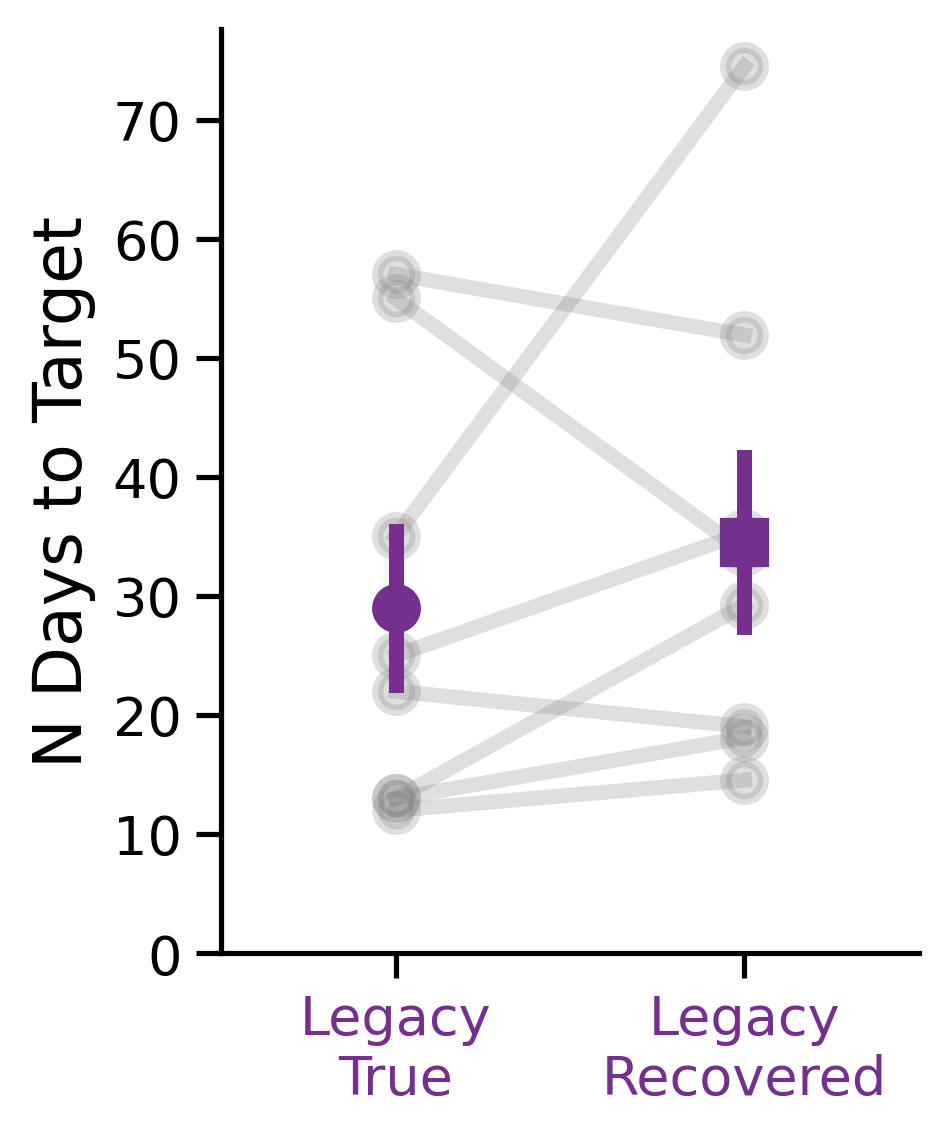

,test_type,group_a,group_b,n_pairs,test_statistic,p_val_raw
0,wilcoxon_signed_rank,legacy_true,recovery,8,12.5,0.484375


,mode,mean,std
0,legacy_true,29.000000,18.369229
1,recovery,34.529167,20.128180


In [9]:
ORDER_B = ["legacy_true", "recovery"]
X_LABELS_B = ["Legacy\nTrue", "Legacy\nRecovered"]
COLORS_B = [config.LEGACY_COLOR, config.LEGACY_COLOR]

fig, ax = plt.subplots(figsize=(3, 4), dpi=300)
plot_days_to_target_comparison(
    ax,
    summary_df,
    order=ORDER_B,
    x_labels=X_LABELS_B,
    marker_colors=COLORS_B,
    tick_colors=COLORS_B,
    markers=["s", "o"],
    n_animals=len(LEGACY_SIM_ANIMALS),
)
save_figure(fig, "suppS2b_legacy_recovery_vs_true")
plt.show()

stats_b = compare_paired_wilcoxon(
    summary_df, "days_to_target", "legacy_true", "recovery"
)
display(stats_b)
display(
    summary_df.query("mode in @ORDER_B")
    .groupby("mode")["days_to_target"]
    .agg(["mean", "std"])
    .reset_index()
)

## Panel C — Legacy perfect vs FixGrower true

Mann–Whitney U test (two-sided). Simulated perfect days-to-target are means over **seeds 0–29** only.


/Users/bredaj/Library/CloudStorage/OneDrive-Cedars-SinaiHealthSystem/github/Breda-Charlton-FixationGrower/src/fixation_grower/plotting.py:332: UserWarning: 
The palette list has fewer values (9) than needed (17) and will cycle, which may produce an uninterpretable plot.
  sns.pointplot(


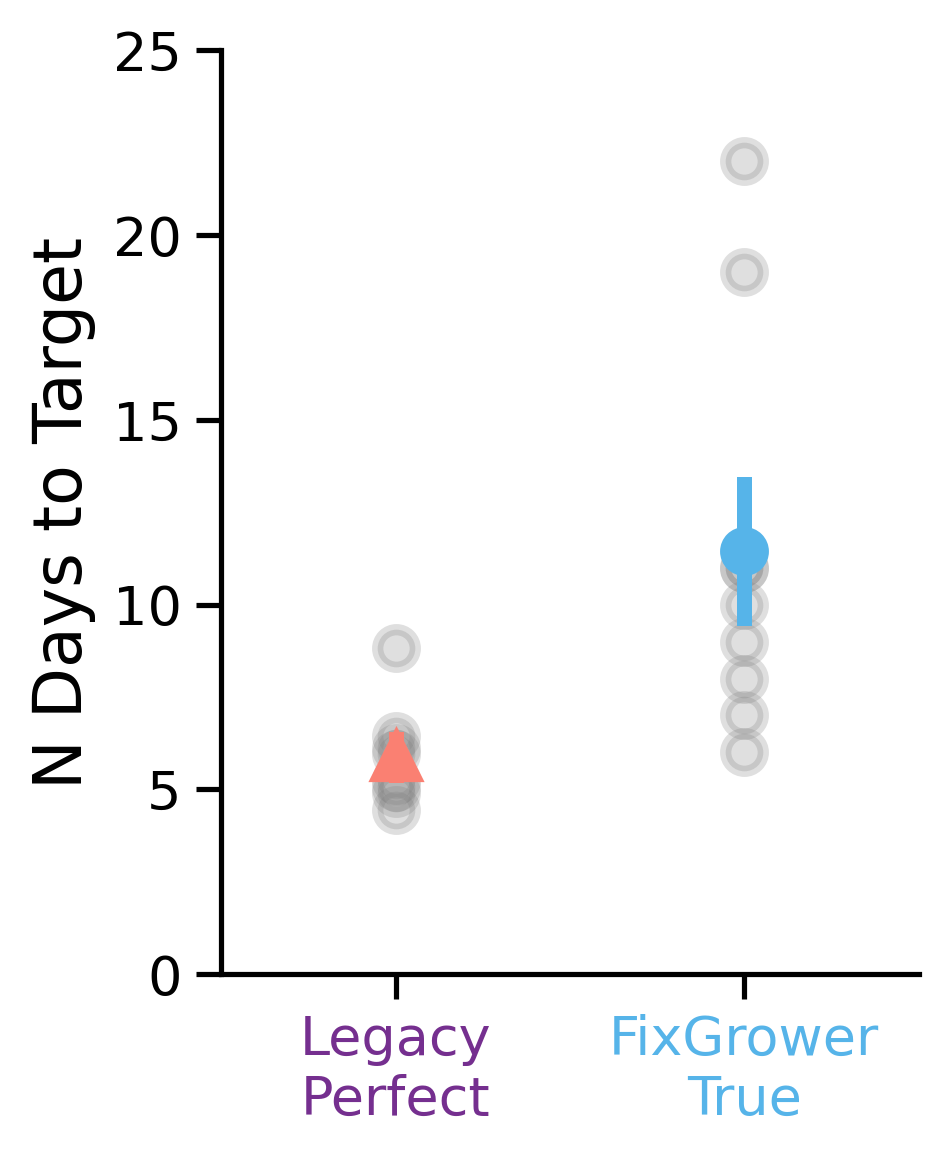

,normality_Legacy,normality_FixGrower,n_Legacy,n_FixGrower,test_type,test_statistic,p_val_raw
0,True,False,8,9,mannwhitney,5.0,0.003318


,mode,mean,std
0,fixgrower_true,11.444444,5.456902
1,perfect,5.879167,1.372743


In [10]:
ORDER_C = ["perfect", "fixgrower_true"]
X_LABELS_C = ["Legacy\nPerfect", "FixGrower\nTrue"]
COLORS_C = ["salmon", config.FIXGROWER_COLOR]
TICK_COLORS_C = [config.LEGACY_COLOR, config.FIXGROWER_COLOR]

fig, ax = plt.subplots(figsize=(3, 4), dpi=300)
plot_days_to_target_comparison(
    ax,
    summary_df,
    order=ORDER_C,
    x_labels=X_LABELS_C,
    marker_colors=COLORS_C,
    tick_colors=TICK_COLORS_C,
    markers=["^", "o"],
    ylim=(0, 25),
    n_animals=max(len(LEGACY_SIM_ANIMALS), len(config.FIXGROWER_ANIMALS)),
)
save_figure(fig, "suppS2c_legacy_perfect_vs_fixgrower_true")
plt.show()

sub_c = summary_df.query("mode in @ORDER_C")
stats_c = compare_legacy_fixgrower(
    sub_c.assign(
        fix_experiment=sub_c["mode"].map(
            {"perfect": "Legacy", "fixgrower_true": "FixGrower"}
        )
    ),
    "days_to_target",
)
display(stats_c)
display(
    sub_c.groupby("mode")["days_to_target"].agg(["mean", "std"]).reset_index()
)